<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U2-T2-V2.2-Modelo vetorial e similaridade</b></h2>


---

# Exemplo 1 - Busca usando TF-IDF

## Um pouco de recuperação de informação

Seja pesquisando o título de um filme ou os filmes de um determinado ator ou de um determinado gênero ou produtos que você procura ou vídeos que deseja assistir, além das recomendações propriamente ditas, busca é uma ferramenta importante para se encontrar os itens desejados.

Como incorporar um mecanismo de busca capaz de encontrar os itens procurados, considerando diversas fontes de evidências? A resposta é usando um **Sistema de Recuperação de Informação**.

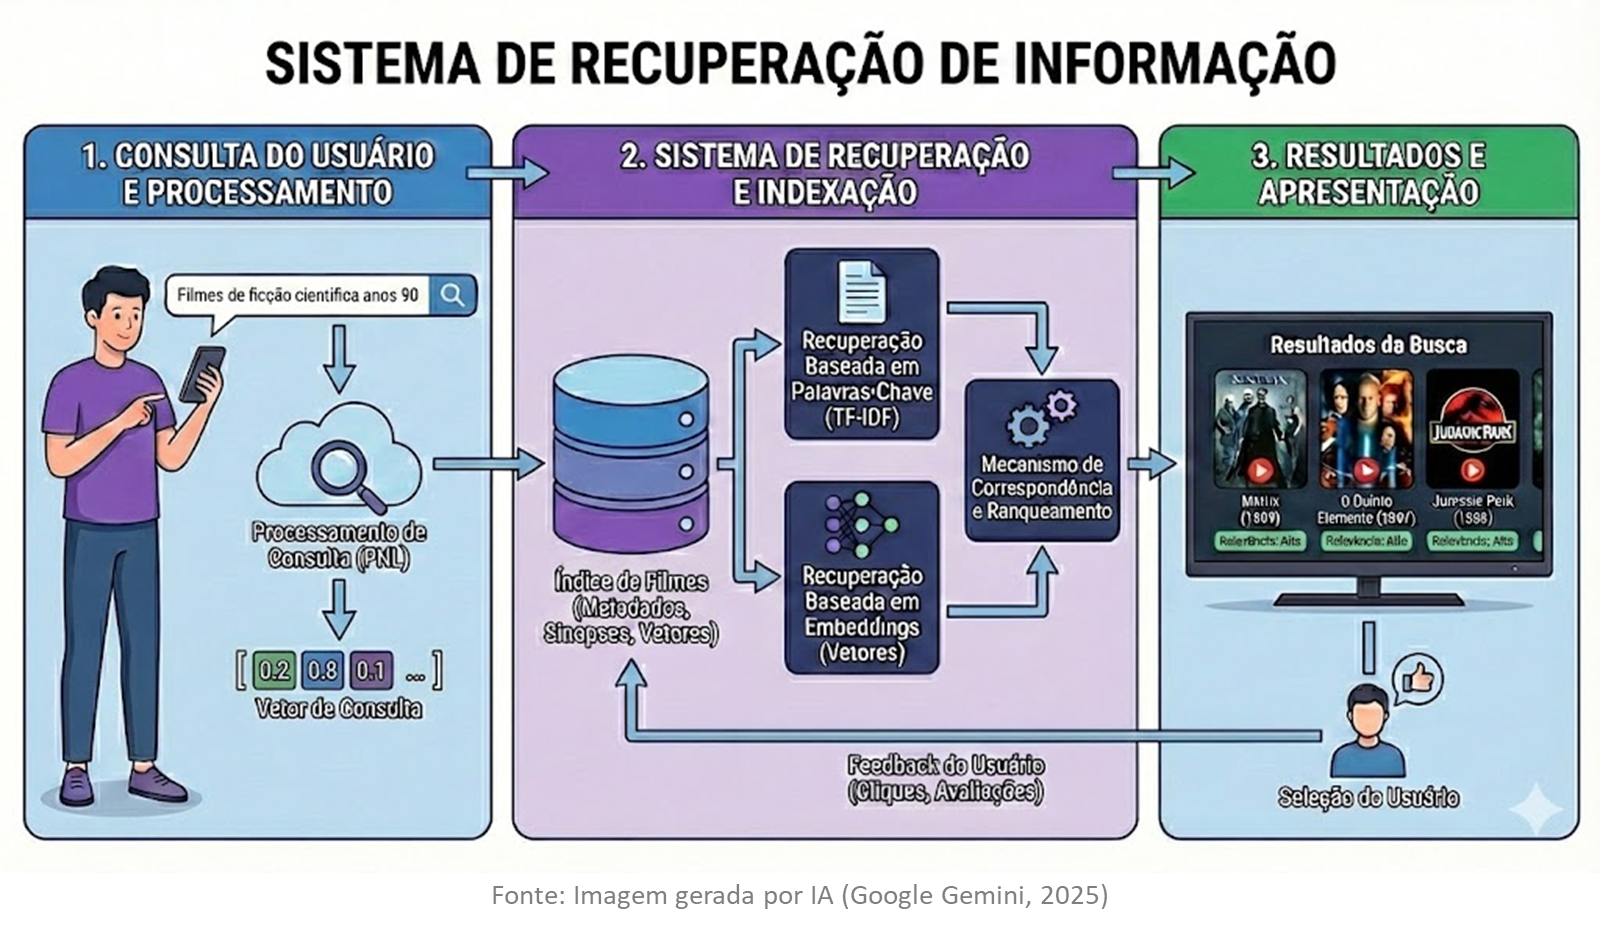

### Modelo Vetorial

O modelo de espaço vetorial ou simplesmente modelo vetorial, é, sem dúvida, o modelo mais conhecido em recuperação de informação.

A idéia central do modelo vetorial é representar algebricamente, como vetores em um espaço euclidiano *t*-dimensional, onde $t$ é o número de termos distintos da coleção, o conjunto de termos de uma consulta
$q$ e dos documentos de uma coleção $D$, conforme figura abaixo:



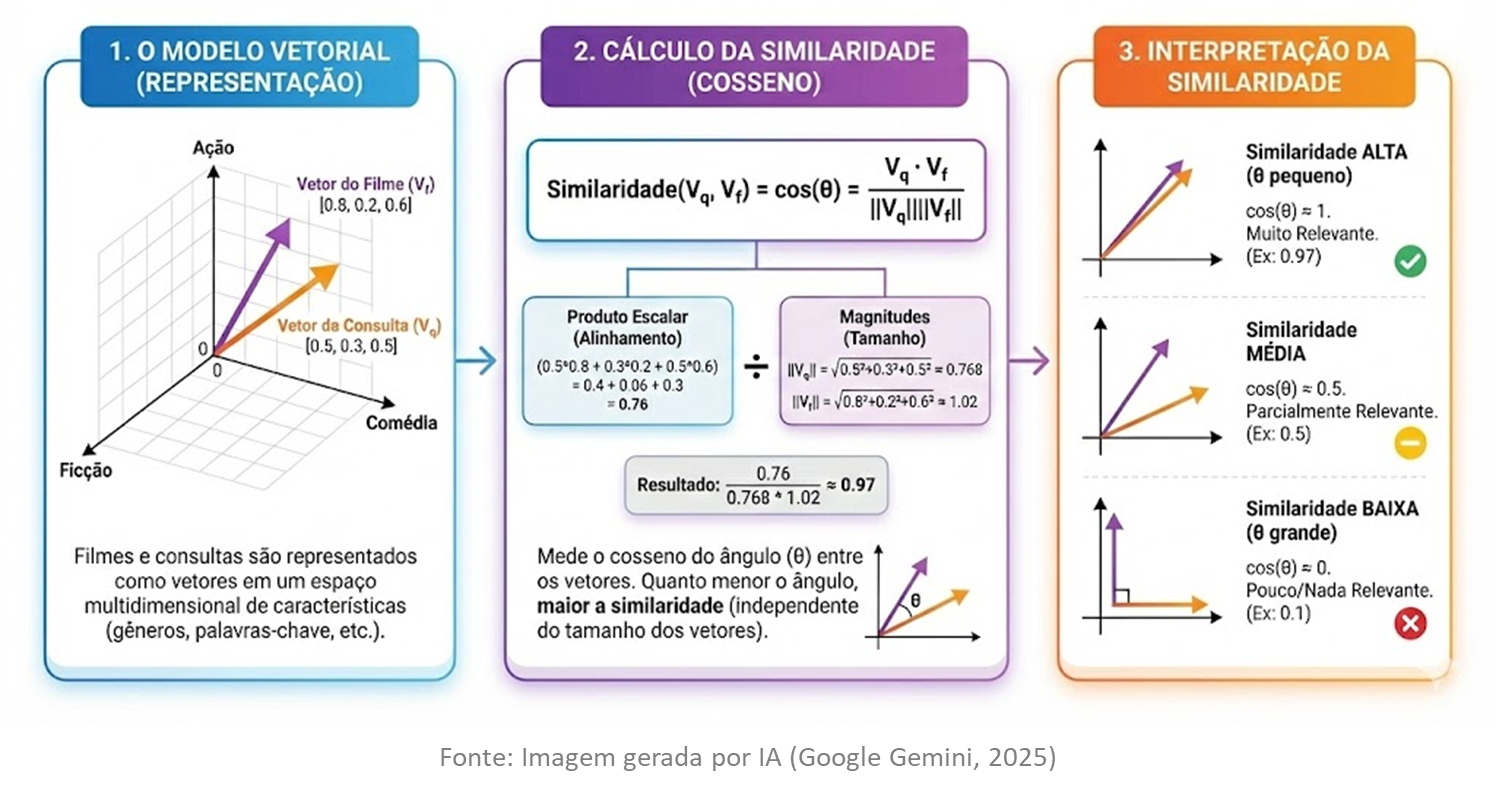

### Representação vetorial

Existem diferentes estratégias para representação vetorial de textos, conforme pode ser visto na figura a seguir.

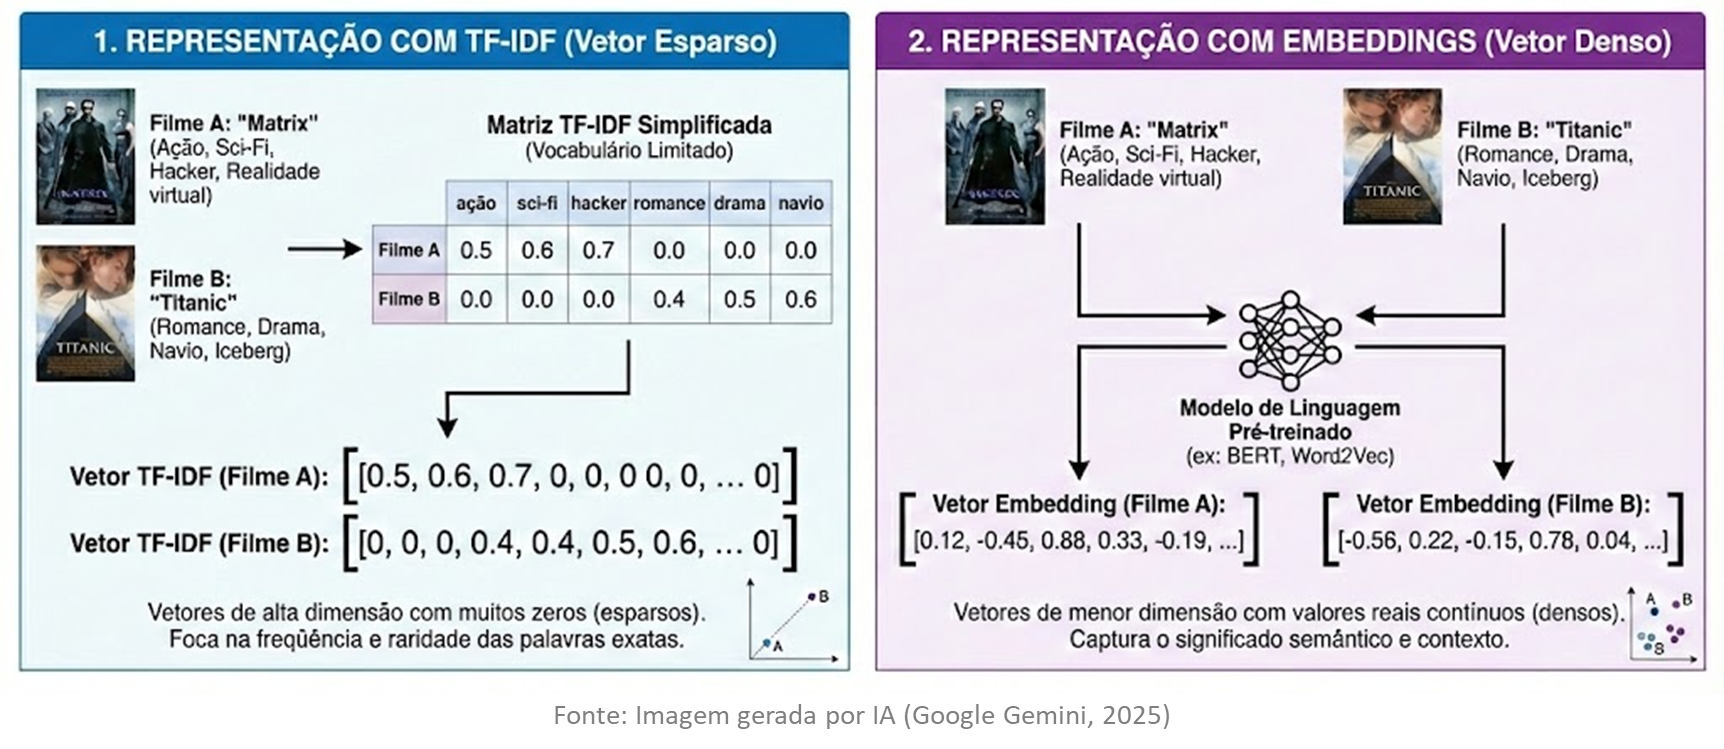

##  Representando filmes como vetores

### Lendo o dataset de filmes

In [21]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [22]:
import pandas as pd
import numpy as np

movies = pd.read_csv('https://drive.google.com/uc?export=download&id=1yjGdaAJ5-YgIUx_1mLTcPqiZ8OI9TeqH', encoding='latin-1', low_memory=False)
movies['tags'] = movies['tags'].apply(lambda x: '' if isinstance(x,float) else x)
movies.set_index('movieId', inplace=True)
movies.head()

,title,genres,tags,tag_count,vote_count,vote_average,imdb_score
movieId,,,,,,,
1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,fun pixar,2,215,3.920930,3.894473
2,Jumanji,Adventure|Children|Fantasy,fantasy magic_board_game game robin_williams,4,110,3.431818,3.419009
3,Grumpier Old Men,Comedy|Romance,old moldy,2,52,3.259615,3.260033
4,Waiting to Exhale,Comedy|Drama|Romance,,0,7,2.357143,2.866377
5,Father of the Bride Part II,Comedy,pregnancy remake,2,49,3.071429,3.101070


Formatando a lista de documentos

In [23]:
raw_documents = [ x + ' ' + ' '.join(y.split('|')) for x,y in movies[['title', 'genres']].values ]
raw_documents[:10]

['Toy Story Adventure Animation Children Comedy Fantasy',
 'Jumanji Adventure Children Fantasy',
 'Grumpier Old Men Comedy Romance',
 'Waiting to Exhale Comedy Drama Romance',
 'Father of the Bride Part II Comedy',
 'Heat Action Crime Thriller',
 'Sabrina Comedy Romance',
 'Tom and Huck Adventure Children',
 'Sudden Death Action',
 'GoldenEye Action Adventure Thriller']

In [24]:
len(raw_documents)

9724

### Representando filmes como vetores TF-IDF


A classe `TfidfVectorizer` gera uma matriz com os valores do peso de cada termo x documento, baseado no TF-IDF, conforme definido abaixo:

$$peso(t_i,d_j) = \frac{w_{i,j}}{\sqrt{\sum_{i=1}^{t} w^{2}_{i,j}}}$$
<br>
onde $w_{i,j}$ é definido comumente por $\left( 1 + \log tf_{i,j} \right) \times \log {\left( 1 + \frac{N}{df_{i}} \right)}$

In [25]:
# Baixar recursos do NLTK
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Criar função para tokenizar, normalizar para minúsculos e remover caracteres especiais

In [26]:
import re
from nltk.tokenize import word_tokenize
import unicodedata

def preprocess(text):
    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    return tokens


In [27]:
documents = [' '.join(preprocess(doc)) for doc in raw_documents]
for d in documents[:5]:
    print(d)

toy story adventure animation children comedy fantasy
jumanji adventure children fantasy
grumpier old men comedy romance
waiting to exhale comedy drama romance
father of the bride part ii comedy


#### Gerando os vetores TF-IDF

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(documents)

pd.DataFrame(tfidf_matrix.todense(), columns=tfidf.get_feature_names_out())

,00,000,007,01,04,06,09,10,100,1000,...,zoom,zootopia,zorn,zorro,zu,zucker,zuiden,zulu,zwartboek,zweig
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9720,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9721,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Executando consultas

A partir da matriz com os valores de TF-IDF será possível executar consultas recuperando os documentos relevantes, de acordo com palavras chaves informadas pelo usuário.

##### Representar a consulta como um vetor TF-IDF

In [29]:
query = 'dead man drama'

tfidf_matrix_query = tfidf.transform([query])

pd.DataFrame(tfidf_matrix_query.todense(), columns=tfidf.get_feature_names_out())

,00,000,007,01,04,06,09,10,100,1000,...,zoom,zootopia,zorn,zorro,zu,zucker,zuiden,zulu,zwartboek,zweig
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Calculando a similaridade da consulta com cada documento

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

print('Calculando a similaridade (medida do cosseno) da consulta com cada documento\n')
sims = cosine_similarity(tfidf_matrix_query, tfidf_matrix)

for d in enumerate(documents[:10]):
    print(f'Similaridade da consulta com o documento "{d[1]}" é {sims[0][d[0]]:.3f}')

Calculando a similaridade (medida do cosseno) da consulta com cada documento

Similaridade da consulta com o documento "toy story adventure animation children comedy fantasy" é 0.000
Similaridade da consulta com o documento "jumanji adventure children fantasy" é 0.000
Similaridade da consulta com o documento "grumpier old men comedy romance" é 0.000
Similaridade da consulta com o documento "waiting to exhale comedy drama romance" é 0.029
Similaridade da consulta com o documento "father of the bride part ii comedy" é 0.000
Similaridade da consulta com o documento "heat action crime thriller" é 0.000
Similaridade da consulta com o documento "sabrina comedy romance" é 0.000
Similaridade da consulta com o documento "tom and huck adventure children" é 0.000
Similaridade da consulta com o documento "sudden death action" é 0.000
Similaridade da consulta com o documento "goldeneye action adventure thriller" é 0.000


##### Retornando os documentos em ordem decrescente de similaridade

In [31]:
print('Retornando os documentos em ordem decrescente de similaridade\n')

print(f'Consulta: "{query}"\n')

for d, score in sorted(enumerate(sims[0]), key=lambda x: x[1], reverse=True)[:10]:
    print(f'Documento "{documents[d]}" ({score:.3f})')


Retornando os documentos em ordem decrescente de similaridade

Consulta: "dead man drama"

Documento "dead man drama mystery western" (0.783)
Documento "dead man walking crime drama" (0.671)
Documento "dead man s shoes crime thriller" (0.616)
Documento "dead man on campus comedy" (0.571)
Documento "evil dead horror" (0.450)
Documento "dead of night horror mystery" (0.437)
Documento "man the action comedy crime" (0.436)
Documento "dead zone the thriller" (0.433)
Documento "dawn of the dead action drama horror" (0.432)
Documento "walking dead the drama war" (0.430)


# Exemplo 2 - Busca usando *embeddings*

## Representando filmes como *embeddings*

### Criando os embeddings dos documentos

Vamos usar uma implementação prática da estratégia **SBERT (Sentence-BERT)** para a geração dos *embeddings*. O **SBERT** é uma modificação do BERT treinada para gerar embeddings de frases/documentos que podem ser comparados diretamente via similaridade de cosseno.

In [32]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
documents[:10]

['toy story adventure animation children comedy fantasy',
 'jumanji adventure children fantasy',
 'grumpier old men comedy romance',
 'waiting to exhale comedy drama romance',
 'father of the bride part ii comedy',
 'heat action crime thriller',
 'sabrina comedy romance',
 'tom and huck adventure children',
 'sudden death action',
 'goldeneye action adventure thriller']

Converter documentos para *embeddings*

In [34]:
embeddings = model.encode(documents, normalize_embeddings=True)
print(embeddings.shape)

(9724, 384)


In [35]:
embeddings[0]

array([-2.20174640e-02,  6.05314691e-03,  1.92260128e-02, -1.27858818e-02,
       -2.45760232e-02,  1.29418410e-02,  9.40868407e-02, -1.10617103e-02,
        2.01334283e-02,  2.06815265e-02, -6.47327397e-04, -4.31975443e-03,
       -4.08434831e-02,  8.75100717e-02,  3.01644281e-02,  3.78154032e-02,
        4.70220335e-02,  4.29881364e-02,  8.48083124e-02, -9.16630700e-02,
        7.88916722e-02,  3.80989723e-02,  9.24282521e-02, -1.86730660e-02,
       -2.09955033e-02,  1.55652594e-02, -9.97356721e-04, -2.37334166e-02,
       -6.72148392e-02, -1.77205503e-02,  5.49540073e-02, -5.63598238e-03,
        2.18419619e-02, -3.70835811e-02,  2.71493830e-02,  2.60837693e-02,
        9.89362784e-03, -3.66269499e-02, -3.63511220e-02,  4.22998518e-03,
       -7.00568482e-02,  2.53709257e-02, -1.89784765e-02, -8.90264660e-02,
        1.40106017e-02,  1.63514353e-02, -5.45971431e-02, -7.71509185e-02,
        5.95381111e-02,  8.51360708e-02, -3.90348919e-02, -4.98535298e-03,
        1.56495825e-03,  

##Executando consultas

A partir dos *embeddings* gerados para cada documento, será possível executar consultas recuperando os documentos relevantes, de acordo com palavras chaves informadas pelo usuário.

Vamos usar a biblioteca **`hnswlib`** para executar uma busca vetorial rápida e eficiente baseada em grafos HNSW.

É muito usada em busca semântica com *embeddings* para encontrar os documentos mais similares em grandes coleções.

In [36]:
!pip install -qU hnswlib

Preparando o índice para a busca

In [37]:
import hnswlib

index = hnswlib.Index(space='cosine', dim=embeddings.shape[1])
index.init_index(max_elements=len(documents))
index.add_items(embeddings)

### Função para pesquisar filmes

In [38]:
def search_movies(query, topN=10):
    embeddings_query = model.encode([query])
    labels, distances = index.knn_query(embeddings_query, k=topN)
    results = []
    for idx,(doc_id, dist) in enumerate(zip(labels[0], distances[0])):
        results.append( ( movies.index[doc_id], idx, 1-dist ) )

    aux1 = pd.DataFrame(results, columns=['movieId', 'rank_pos', 'rank_score']).set_index('movieId')
    aux2 = movies[['title', 'genres', 'tags','imdb_score']]
    aux1 = aux1.join(aux2, on='movieId')
    return aux1.sort_values(by=['rank_score', 'imdb_score'], ascending=False)[:topN]

search_movies('dead man drama')

,rank_pos,rank_score,title,genres,tags,imdb_score
movieId,,,,,,
2976,0,0.823092,Bringing Out the Dead,Drama,,3.324136
3250,1,0.781883,Alive,Drama,in_netflix_queue,3.214557
1246,2,0.727467,Dead Poets Society,Drama,highschool high_school,3.893285
110603,3,0.726063,God's Not Dead,Drama,,2.986203
714,4,0.713696,Dead Man,Drama|Mystery|Western,,3.702585
36,5,0.705647,Dead Man Walking,Crime|Drama,death_penalty nun,3.767922
1382,6,0.695514,Marked for Death,Action|Drama,,2.835541
37475,7,0.688997,"Unfinished Life, An",Drama,,3.236203
3431,8,0.683534,Death Wish 2,Action|Drama,,2.863503


In [39]:
search_movies('godfather')

,rank_pos,rank_score,title,genres,tags,imdb_score
movieId,,,,,,
858,0,0.828444,"Godfather, The",Crime|Drama,mafia,4.243095
1221,1,0.757246,"Godfather: Part II, The",Crime|Drama,al_pacino mafia,4.194652
2023,2,0.728663,"Godfather: Part III, The",Crime|Drama|Mystery|Thriller,mafia classic andy_garcia francis_ford_coppola...,3.340038
8607,3,0.597968,Tokyo Godfathers,Adventure|Animation|Drama,in_netflix_queue,3.490145
172591,4,0.570134,The Godfather Trilogy: 1972-1990,(no genres listed),,3.532912
99728,5,0.554282,Gangster Squad,Action|Crime|Drama,,3.280170
5423,6,0.547142,Gangster No. 1,Action|Crime|Thriller,,3.196836
55765,7,0.531218,American Gangster,Crime|Drama|Thriller,corruption denzel_washington organized_crime m...,3.779609
1601,8,0.519551,Hoodlum,Crime|Drama|Film-Noir,,3.030170


In [40]:
search_movies('toy story')

,rank_pos,rank_score,title,genres,tags,imdb_score
movieId,,,,,,
4929,0,0.715374,"Toy, The",Comedy,,2.989387
2253,1,0.694363,Toys,Comedy|Fantasy,,2.650415
1,2,0.669426,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,fun pixar,3.894473
3114,3,0.657099,Toy Story 2,Adventure|Animation|Children|Comedy|Fantasy,tom_hanks original pixar animation disney funn...,3.810019
5843,4,0.640075,Toy Soldiers,Action|Drama,,3.027849
78499,5,0.616998,Toy Story 3,Adventure|Animation|Children|Comedy|Fantasy|IMAX,,3.990032
108932,6,0.534271,The Lego Movie,Action|Adventure|Animation|Children|Comedy|Fan...,colorful feel-good quirky fun clever cheeky im...,3.734051
1654,7,0.517406,FairyTale: A True Story,Children|Drama|Fantasy,,3.286203
3086,8,0.517381,Babes in Toyland,Children|Comedy|Fantasy|Musical,,3.436203
